# Demand thresholds for the EMS

Goal: convert the May load profile into simple low, medium, and high demand states.

The app does not need the minimum and maximum as thresholds. It only needs two separation
points:

- low demand: demand below the 25 percent quantile
- medium demand: demand between the 25 percent and 75 percent quantiles
- high demand: demand above the 75 percent quantile

The values stay in mW because this is the EMS scale used by the demonstration system.


In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# This makes the notebook work both from the repo root and from its own folder.
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "data").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("Could not find the project root folder containing data/")
    PROJECT_ROOT = PROJECT_ROOT.parent

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 120)


## 1. Load and inspect the raw demand profile


In [5]:
demand_file = PROJECT_ROOT / "EMS Control App/python/data/variable_load_signal/scaled_may_power_profile_15min.csv"

demand_raw = pd.read_csv(demand_file)

print("File:", demand_file)
print("Rows:", len(demand_raw))
display(demand_raw.head())
display(demand_raw.describe())


File: C:\Users\Jacob\My Drive\DTU\Bachelor Projekt\Code\Bachelor_repo\Bachelor\EMS Control App\python\data\variable_load_signal\scaled_may_power_profile_15min.csv
Rows: 96


,time_slot,time_of_day,power_mW
0,1,00:00,34.314081
1,2,00:15,33.782637
2,3,00:30,33.251193
3,4,00:45,32.719750
4,5,01:00,32.188306


,time_slot,power_mW
count,96.000000,96.000000
mean,48.500000,41.833295
std,27.856777,15.202156
min,1.000000,15.000000
25%,24.750000,32.485548
50%,48.500000,42.522679
75%,72.250000,49.506691
max,96.000000,75.000000


## 2. Plot the demand profile

I first plot the data directly. This checks that the profile has the expected 24 hour shape and
that the numbers are already in mW.


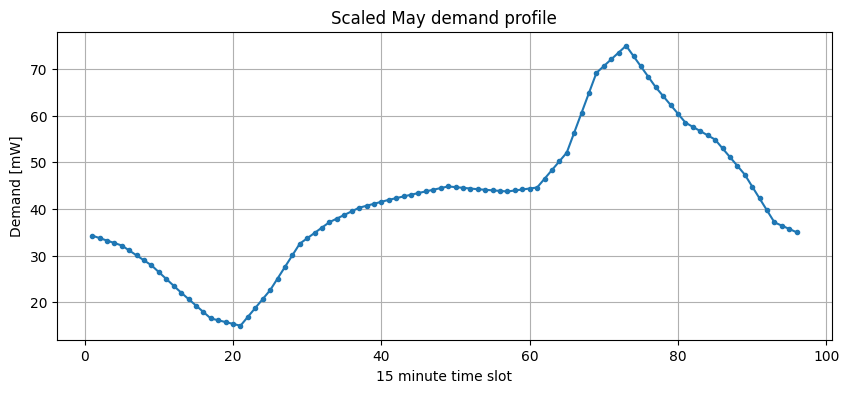

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(demand_raw["time_slot"], demand_raw["power_mW"], marker="o", markersize=3)
plt.title("Scaled May demand profile")
plt.xlabel("15 minute time slot")
plt.ylabel("Demand [mW]")
plt.grid(True)
plt.show()


## 3. Calculate the two state thresholds


In [7]:
demand_mW = demand_raw["power_mW"].astype(float)

LOW_DEMAND_THRESHOLD_MILLIWATT = demand_mW.quantile(0.25)
HIGH_DEMAND_THRESHOLD_MILLIWATT = demand_mW.quantile(0.75)
MIN_DEMAND_MILLIWATT = demand_mW.min()
MAX_DEMAND_MILLIWATT = demand_mW.max()

print(f"Low/medium threshold:  {LOW_DEMAND_THRESHOLD_MILLIWATT:.2f} mW")
print(f"Medium/high threshold: {HIGH_DEMAND_THRESHOLD_MILLIWATT:.2f} mW")
print(f"Minimum demand in profile: {MIN_DEMAND_MILLIWATT:.2f} mW")
print(f"Maximum demand in profile: {MAX_DEMAND_MILLIWATT:.2f} mW")


Low/medium threshold:  32.49 mW
Medium/high threshold: 49.51 mW
Minimum demand in profile: 15.00 mW
Maximum demand in profile: 75.00 mW


## 4. Check the split visually

The histogram should show that the thresholds divide the profile into lower, middle, and upper
demand regions. They are not physical limits. They are only state-classification thresholds.


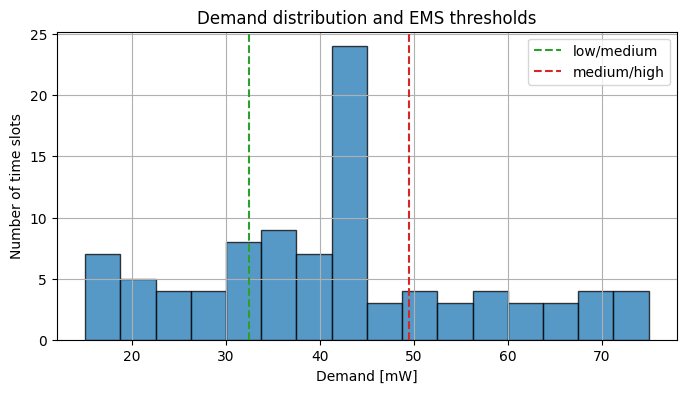

In [8]:
plt.figure(figsize=(8, 4))
plt.hist(demand_mW, bins=16, edgecolor="black", alpha=0.75)
plt.axvline(LOW_DEMAND_THRESHOLD_MILLIWATT, color="tab:green", linestyle="--", label="low/medium")
plt.axvline(HIGH_DEMAND_THRESHOLD_MILLIWATT, color="tab:red", linestyle="--", label="medium/high")
plt.title("Demand distribution and EMS thresholds")
plt.xlabel("Demand [mW]")
plt.ylabel("Number of time slots")
plt.legend()
plt.grid(True)
plt.show()


## 5. Values to use in the app


In [9]:
demand_parameters = pd.DataFrame(
    {
        "parameter": [
            "LOW_DEMAND_THRESHOLD_MILLIWATT",
            "HIGH_DEMAND_THRESHOLD_MILLIWATT",
            "MAX_DEMAND_MILLIWATT",
        ],
        "value": [
            LOW_DEMAND_THRESHOLD_MILLIWATT,
            HIGH_DEMAND_THRESHOLD_MILLIWATT,
            MAX_DEMAND_MILLIWATT,
        ],
        "unit": ["mW", "mW", "mW"],
        "meaning": [
            "Below this is low demand",
            "Above this is high demand",
            "The largest load the demo EMS is scaled to cover",
        ],
    }
)

display(demand_parameters)


,parameter,value,unit,meaning
0,LOW_DEMAND_THRESHOLD_MILLIWATT,43.314065,mW,Below this is low demand
1,HIGH_DEMAND_THRESHOLD_MILLIWATT,66.008921,mW,Above this is high demand
2,MAX_DEMAND_MILLIWATT,100.000000,mW,The largest load the demo EMS is scaled to cover
